In [1]:
from pathlib import Path

model_dir = Path(r"D:\wuzm\models\Z-Image-Turbo-int4-ov")

from notebook_utils import device_widget

device = device_widget(default="AUTO", exclude=["NPU"])
device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

In [2]:
from optimum.intel import OVZImagePipeline

ov_pipe = OVZImagePipeline.from_pretrained(model_dir, device=device.value)
print("✅ 模型加载完成")

Multiple distributions found for package optimum. Picked distribution: optimum
D:\Software\anaconda3\envs\openvino\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


✅ 模型加载完成


  0%|          | 0/5 [00:00<?, ?it/s]

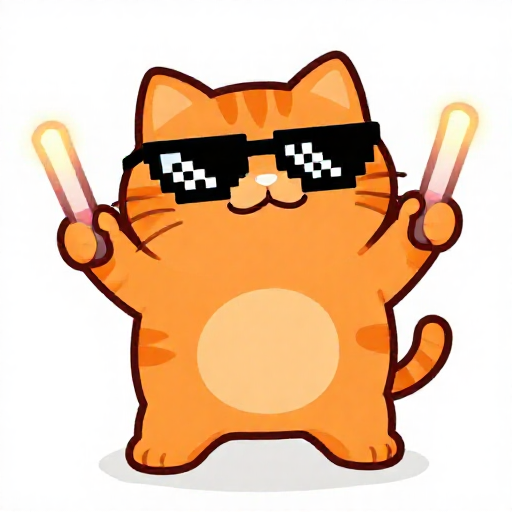

In [5]:
import torch

prompt = "一只胖乎乎的橘猫，戴着复古像素墨镜，正举着两根发光的荧光棒疯狂摇摆，嘴角上扬表情极其嚣张得意。夸张的2D美式卡通风格，线条粗犷，色彩高饱和，微信表情包，纯白干净背景，矢量插画质感，超清细节。"

image = ov_pipe(
    prompt=prompt,
    height=512,
    width=512,
    num_inference_steps=5,
    guidance_scale=0.0,
    generator=torch.Generator("cpu").manual_seed(42),
).images[0]

image

In [5]:
ov_pipe

OVZImagePipeline {
  "_class_name": "OVZImagePipeline",
  "_diffusers_version": "0.36.0.dev0",
  "_name_or_path": "Tongyi-MAI/Z-Image-Turbo",
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "optimum.intel.openvino.modeling_diffusion",
    "OVModelTextEncoder"
  ],
  "tokenizer": [
    "transformers",
    "Qwen2Tokenizer"
  ],
  "transformer": [
    "optimum.intel.openvino.modeling_diffusion",
    "OVModelTransformer"
  ],
  "vae": [
    "optimum.intel.openvino.modeling_diffusion",
    "OVModelVae"
  ]
}

In [ ]:
from gradio_helper_zimage import make_demo

demo = make_demo(ov_pipe)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


  0%|          | 0/9 [00:00<?, ?steps/s]